# MDR-TS v7.3
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v7.3
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

Squeezing out as much R^2 as possible using post-hoc calibration


For other info see `MDR-TS-v1.0`

## 0. Imports

In [25]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [65]:
# Project paths
VERSION = "v7"
SUBVERSION = "v7.3"
RUN_NAME = "mdr_ts_v7_3"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR/"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR/
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.3

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_new/train_derived_new.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_new/val_derived_new.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_new/test_derived_new.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/train_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/val_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/test_derived_new.csv
train: dropped columns ['slope', 'elev']

train: shape=(16972, 352)
train: columns=352
val: dropped columns ['slope', 'elev']

val: shape=(2919, 352)
val: columns=352
test: dropped columns ['slope', 'elev']

test: shape=(2829, 352)
test: columns=352


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 352

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_d_G_API_kobs5', 'A_d_G_API_kobs7', 'A_d_G_API_kobs14']


## 4. Data Sanity Checks

In [6]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
  "precip_mm",

  "G_rain_sum_3d",
  "G_rain_sum_7d",
  "G_rain_sum_30d",
  "G_API",

  "G_DSLR",

  "C_lag_E_SAR_diff_kobs12",
  "C_lag_E_SAR_diff_kobs30",
  "C_lag_E_SAR_ratio_kobs30",
  "C_lag_F_NDVI_kobs30",
  "C_lag_LST_modis_kobs12",
  "C_lag_LST_modis_kobs30",
  "DOY",
  "D_sa_E_SAR_ratio",
  "D_sa_F_NDMI",
  "D_z_E_SAR_ratio",
  "D_z_F_NDMI",
  "E_SAR_diff",
  "E_SAR_ratio",
  "F_MSI",
  "F_NDMI",
  "V_ema_LST_modis_kobs30",
  "V_rollmax_E_SAR_diff_kobs14",
  "V_rollmax_E_SAR_diff_kobs30",
  "V_rollmax_F_NDVI_kobs30",
  "V_rollmax_G_API_kobs30",
  "V_rollmax_G_API_kobs7",
  "V_rollmax_LST_modis_kobs7",
  "V_rollmax_s2_b11_kobs30",
  "V_rollmean_G_API_kobs30",
  "V_rollmin_E_SAR_diff_kobs30",
  "V_rollmin_E_SAR_ratio_kobs30",
  "V_rollmin_F_NDMI_kobs30",
  "V_rollmin_G_API_kobs7",
  "V_rollmin_s2_b11_kobs30",
  "V_rollmin_s2_b12_kobs30",
  "s1_vh",
  "s2_b8",
  "A_d_LST_modis_kobs7",
  "A_grad_LST_modis_kobs14",
  "C_lag_E_SAR_diff_kobs6",
  "V_rollmax_E_SAR_diff_kobs7",
  "V_rollmax_E_SAR_ratio_kobs14",
  "V_rollmax_F_NDVI_kobs14",
  "s2_b12",
  "D_sa_LST_modis"
]

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 46
  Target:   soil_moisture_5cm


In [7]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[WARN] station Touchet_WA_824: missing split data (train=3311, val=0, test=170)

[WARNING] 1 station(s) have temporal leakage or split issues.


In [8]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Touchet_WA_824:
    train max date: 2020-10-28 00:00:00
    val   min date: NaT


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     16972
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2829
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [10]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (16972, 46)
  X_val:   (2919, 46)
  X_test:  (2829, 46)
  y_train: (16972,)


### 6.2 Feature Overview

In [11]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
G_rain_sum_30d,1.297717e+02,146.101615,0.000000,1100.500000
DOY,1.856803e+02,102.681888,1.000000,366.000000
V_rollmax_G_API_kobs30,7.421912e+01,72.224672,0.225530,408.757381
V_rollmax_G_API_kobs7,5.376347e+01,59.531471,0.022210,408.757381
G_API,4.304036e+01,50.740737,0.000000,408.757381
G_rain_sum_7d,3.423221e+01,48.772041,0.000000,477.000000
V_rollmean_G_API_kobs30,4.318955e+01,45.947859,0.075323,313.507425
V_rollmin_G_API_kobs7,3.331444e+01,40.806878,0.000000,337.178315
G_rain_sum_3d,1.721288e+01,28.434613,0.000000,259.400000
C_lag_LST_modis_kobs12,2.875310e+02,11.630057,248.913937,316.363128


### 6.3 Feature Correlation

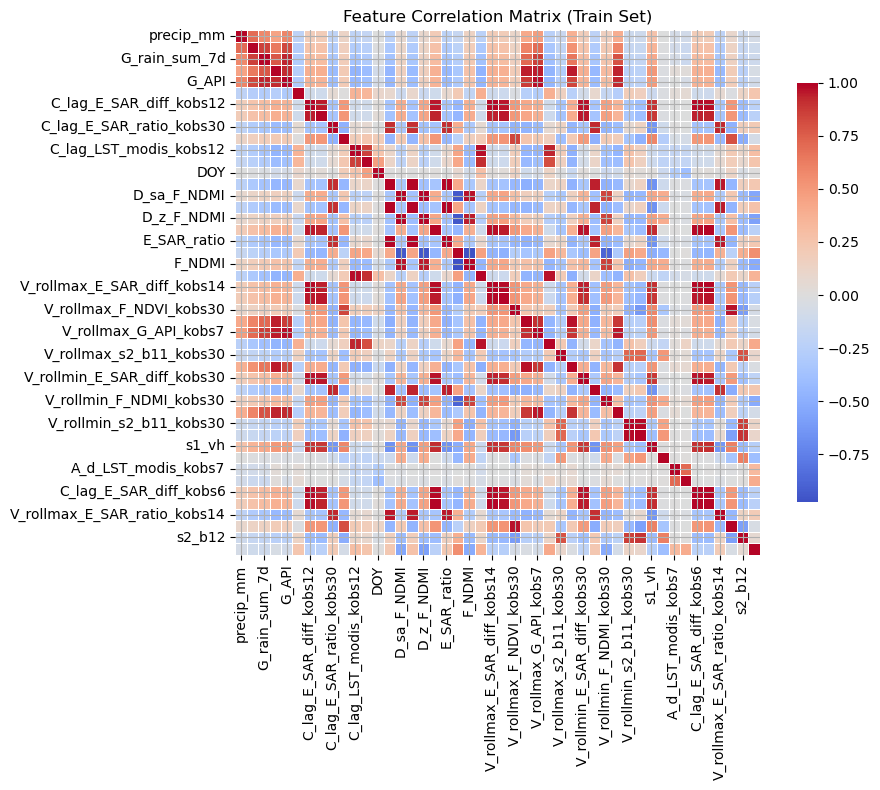

In [12]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

### 6.4 Baseline Model Definition

In [13]:
MODEL_CONFIG_FINAL = {
    "n_estimators": 5000,
    "max_depth": 5,
    "learning_rate": 0.03,
    "min_child_weight": 8,
    "gamma": 0.5,
    "subsample": 0.75,
    "colsample_bytree": 0.75,
    "reg_alpha": 0.05,
    "reg_lambda": 3.0,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
}

In [14]:
model = XGBRegressor(**MODEL_CONFIG_FINAL)
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.75, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.5, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=8, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=5000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)


## 7. Training Loop

### 7.1 Fit Model

In [15]:
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)
yhat_train = model.predict(X_train)
yhat_val   = model.predict(X_val)
yhat_test  = model.predict(X_test)

print("Predictions generated")
print("  yhat_train:", yhat_train.shape)
print("  yhat_val:  ", yhat_val.shape)
print("  yhat_test: ", yhat_test.shape)

[0]	validation_0-rmse:0.09995	validation_1-rmse:0.10142
[50]	validation_0-rmse:0.05018	validation_1-rmse:0.05354
[100]	validation_0-rmse:0.04407	validation_1-rmse:0.04805
[150]	validation_0-rmse:0.04377	validation_1-rmse:0.04787
[200]	validation_0-rmse:0.04371	validation_1-rmse:0.04785
[250]	validation_0-rmse:0.04371	validation_1-rmse:0.04783
[300]	validation_0-rmse:0.04369	validation_1-rmse:0.04781
[350]	validation_0-rmse:0.04369	validation_1-rmse:0.04783
[400]	validation_0-rmse:0.04369	validation_1-rmse:0.04781
[450]	validation_0-rmse:0.04369	validation_1-rmse:0.04780
[500]	validation_0-rmse:0.04369	validation_1-rmse:0.04779
[550]	validation_0-rmse:0.04369	validation_1-rmse:0.04781
[600]	validation_0-rmse:0.04369	validation_1-rmse:0.04781
[650]	validation_0-rmse:0.04369	validation_1-rmse:0.04781
[700]	validation_0-rmse:0.04364	validation_1-rmse:0.04781
[750]	validation_0-rmse:0.04364	validation_1-rmse:0.04781
[800]	validation_0-rmse:0.04364	validation_1-rmse:0.04781
[850]	validation_

In [38]:
yhat_train_np = np.asarray(yhat_train).ravel()
yhat_val_np   = np.asarray(yhat_val).ravel()
yhat_test_np  = np.asarray(yhat_test).ravel()

y_train_np = np.asarray(y_train).ravel()
y_val_np   = np.asarray(y_val).ravel()
y_test_np  = np.asarray(y_test).ravel()

# ---------- sanity: confirm we're calibrating the same XGB preds ----------
print("Base XGB test R2:", float(r2_score(y_test_np, yhat_test_np)))
print("Base XGB val  R2:", float(r2_score(y_val_np,  yhat_val_np)))
print("Base XGB test bias (true-pred):", float(np.mean(y_test_np - yhat_test_np)))
print()


Base XGB test R2: 0.7576945239474714
Base XGB val  R2: 0.7747203994143402
Base XGB test bias (true-pred): 0.012184084746548127



In [39]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

alphas = np.logspace(-6, 3, 15)  # 1e-6 ... 1e3
best = None

for a in alphas:
    cal_tmp = Ridge(alpha=a)
    cal_tmp.fit(yhat_val_np.reshape(-1, 1), y_val_np)
    yhat_val_cal_tmp = cal_tmp.predict(yhat_val_np.reshape(-1, 1))
    r2_val = r2_score(y_val_np, yhat_val_cal_tmp)

    if (best is None) or (r2_val > best["r2_val"]):
        best = {
            "alpha": a,
            "r2_val": float(r2_val),
            "slope": float(cal_tmp.coef_[0]),
            "intercept": float(cal_tmp.intercept_),
        }

print("Best Ridge (selected on VAL):")
print("  alpha     =", best["alpha"])
print("  slope a   =", best["slope"])
print("  intercept =", best["intercept"])
print("  val R2    =", best["r2_val"])

Best Ridge (selected on VAL):
  alpha     = 1e-06
  slope a   = 1.0988717079162598
  intercept = 0.00426889955997467
  val R2    = 0.837025533882867


In [40]:
cal = Ridge(alpha=best["alpha"])
cal.fit(yhat_val_np.reshape(-1, 1), y_val_np)

,alpha,1e-06
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [41]:
yhat_train_cal = cal.predict(np.asarray(yhat_train).reshape(-1, 1))
yhat_val_cal   = cal.predict(np.asarray(yhat_val).reshape(-1, 1))
yhat_test_cal  = cal.predict(np.asarray(yhat_test).reshape(-1, 1))

### 7.2 Metrics

In [59]:
def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_mean(true-pred)": float(np.mean(y_true - y_pred)),
    }

results_before = [
    metrics_block("train", y_train, yhat_train),
    metrics_block("val",   y_val,   yhat_val),
    metrics_block("test",  y_test,  yhat_test),
]

results_after = [
    metrics_block("train", y_train, yhat_train_cal),
    metrics_block("val",   y_val,   yhat_val_cal),
    metrics_block("test",  y_test,  yhat_test_cal),
]

results_before = pd.DataFrame(results_before)
results_after = pd.DataFrame(results_after)

print("\nBEFORE:")
display(pd.DataFrame(results_before))

print("\nAFTER (post-hoc calibrated):")
display(pd.DataFrame(results_after))



BEFORE:


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.034470,0.043565,0.818483,0.000045
1,val,0.036769,0.047804,0.774720,0.023734
2,test,0.036493,0.046039,0.757695,0.012184



AFTER (post-hoc calibrated):


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.038399,0.048168,0.778098,-2.348640e-02
1,val,0.031648,0.040660,0.837026,-1.138516e-08
2,test,0.034252,0.045696,0.761296,-1.228967e-02


### 7.3 Diagnostics

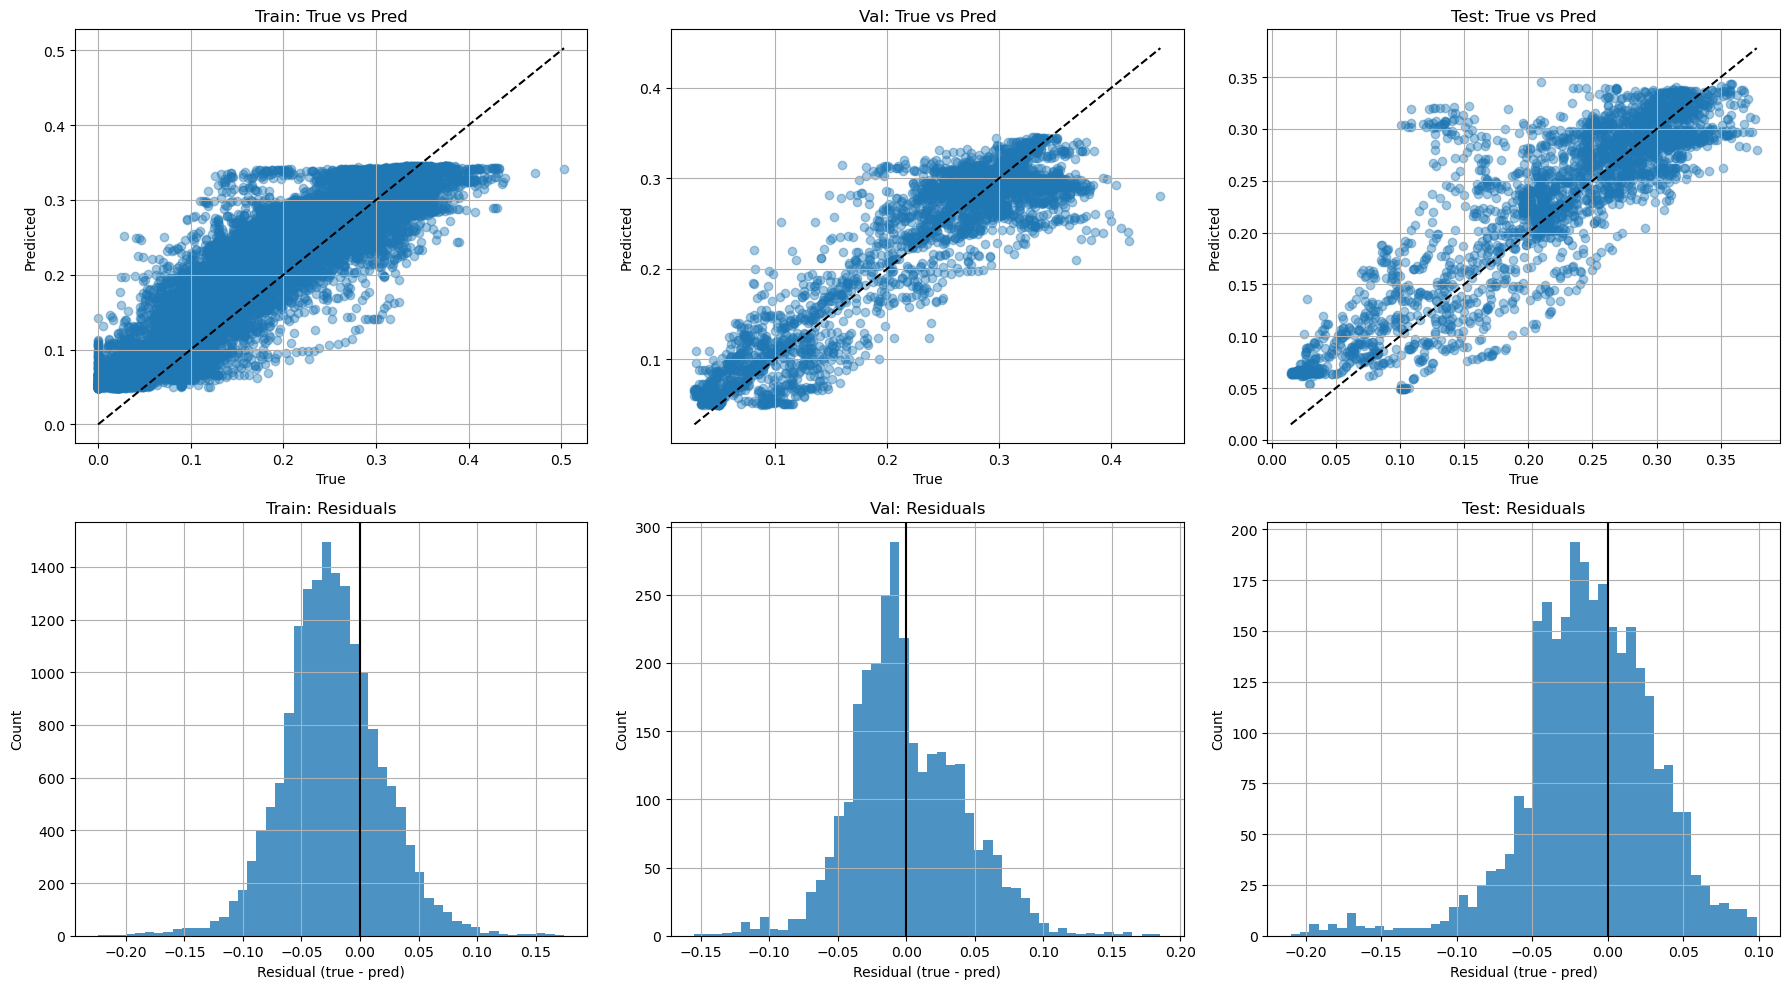

In [44]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train_cal, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val_cal,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test_cal,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train_cal, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val_cal,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test_cal,  "Test: Residuals")

plt.tight_layout()
plt.show()

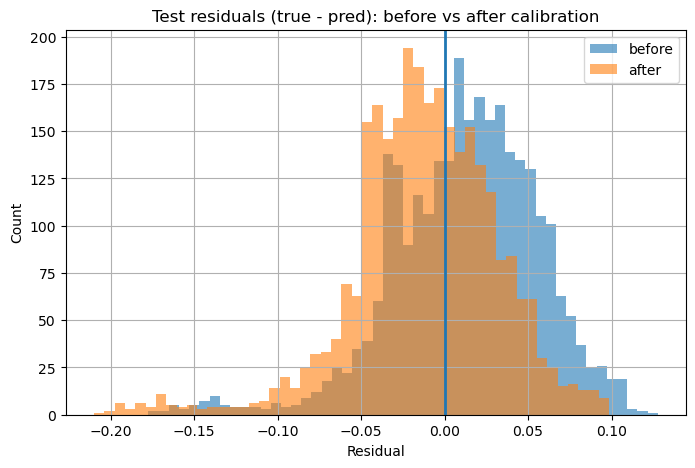

In [45]:
res_before = y_test - yhat_test
res_after  = y_test - yhat_test_cal

plt.figure()
plt.hist(res_before, bins=50, alpha=0.6, label="before")
plt.hist(res_after,  bins=50, alpha=0.6, label="after")
plt.axvline(0, linewidth=2)
plt.title("Test residuals (true - pred): before vs after calibration")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend()
plt.show()

### 7.4 Feature Importance

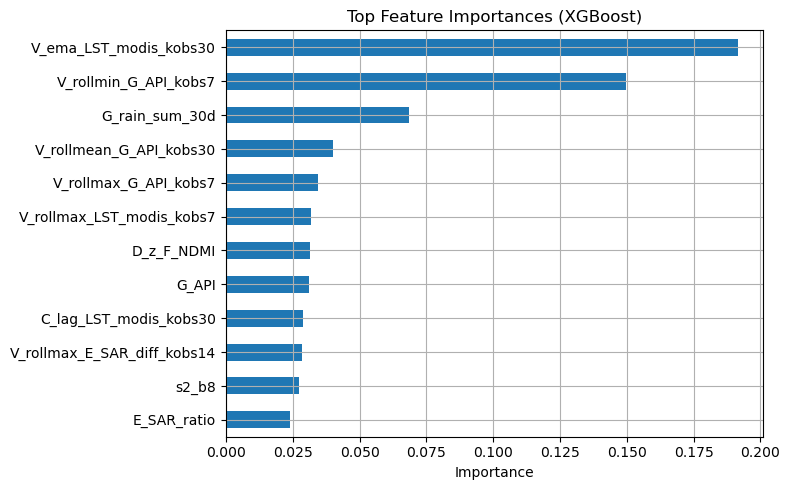

V_ema_LST_modis_kobs30          0.191431
V_rollmin_G_API_kobs7           0.149842
G_rain_sum_30d                  0.068562
V_rollmean_G_API_kobs30         0.040182
V_rollmax_G_API_kobs7           0.034561
V_rollmax_LST_modis_kobs7       0.031782
D_z_F_NDMI                      0.031409
G_API                           0.030980
C_lag_LST_modis_kobs30          0.028743
V_rollmax_E_SAR_diff_kobs14     0.028422
s2_b8                           0.027449
E_SAR_ratio                     0.023870
DOY                             0.020774
D_sa_F_NDMI                     0.020268
C_lag_E_SAR_diff_kobs6          0.019215
G_rain_sum_7d                   0.016874
V_rollmin_F_NDMI_kobs30         0.014065
V_rollmin_E_SAR_diff_kobs30     0.013975
G_DSLR                          0.012078
C_lag_LST_modis_kobs12          0.011601
V_rollmin_s2_b11_kobs30         0.011299
V_rollmax_G_API_kobs30          0.010314
G_rain_sum_3d                   0.010304
C_lag_E_SAR_diff_kobs12         0.010228
V_rollmin_E_SAR_

In [46]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 8. Evaluation

### 8.1 Test Metrics

In [47]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test_cal),
    "RMSE": rmse(y_test, yhat_test_cal),
    "R2":   r2_score(y_test, yhat_test_cal),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.034252,0.045696,0.761296,2829


### 8.2 Test Prediction Scatter

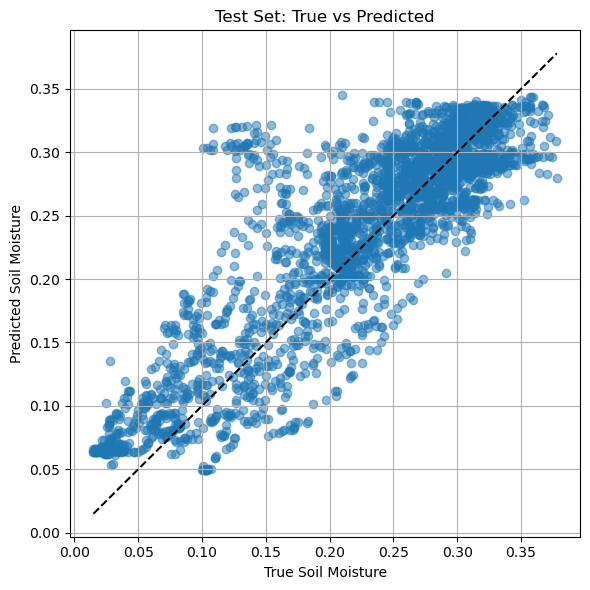

In [48]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test_cal, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [49]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val_cal).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test_cal).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val_cal.min()): .6f} to {float(yhat_val_cal.max()): .6f}
TEST range : {float(yhat_test_cal.min()): .6f} to {float(yhat_test_cal.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean : -0.000000
TEST residual mean : -0.012290

Prediction ranges
-----------------
VAL  range :  0.049167 to  0.345460
TEST range :  0.049167 to  0.345036



## 9. Metrics & Visalization

### 9.1 Generalization Gap

In [61]:
gap = {
    "train -> val (MAE)": float(results_after.loc["val", "MAE"] - results_after.loc["train", "MAE"]),
    "val -> test (MAE)":  float(results_after.loc["test", "MAE"] - results_after.loc["val", "MAE"]),
}
pd.DataFrame.from_dict(gap, orient="index", columns=["delta_MAE"])

KeyError: 'val'

### 9.2 Feature Importance Recap

In [24]:
importances.head(10)

V_ema_LST_modis_kobs30         0.191431
V_rollmin_G_API_kobs7          0.149842
G_rain_sum_30d                 0.068562
V_rollmean_G_API_kobs30        0.040182
V_rollmax_G_API_kobs7          0.034561
V_rollmax_LST_modis_kobs7      0.031782
D_z_F_NDMI                     0.031409
G_API                          0.030980
C_lag_LST_modis_kobs30         0.028743
V_rollmax_E_SAR_diff_kobs14    0.028422
dtype: float32

## 10. Save Artifacts

In [53]:
from datetime import datetime

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260117_165132


In [54]:
MODEL_PATH = os.path.join(RUN_DIR, "model.json")
model.save_model(MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260117_165132/model.json


In [56]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v1.0",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config": MODEL_CONFIG_FINAL,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)

Run metadata saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260117_165132/run_metadata.json


In [62]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results_after.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260117_165132/metrics.csv


In [63]:
IMPORTANCE_PATH = os.path.join(RUN_DIR, "feature_importance.csv")
importances.to_csv(IMPORTANCE_PATH, header=["importance"])

print("Feature importance saved to:")
print(IMPORTANCE_PATH)

Feature importance saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260117_165132/feature_importance.csv


In [64]:
# save key figures
FIG_DIR = os.path.join(RUN_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

---

_Jakob Balkovec_